# Cost Models for `bt.Backtest`: Almgren-Chriss vs. Default

This notebook compares a vanilla `bt.Backtest` (cost-free baseline) against a
`bt.Backtest` driven by an Almgren-Chriss cost model passed as `commissions`.
The setup is chosen to make market-impact costs *visible*: 1 billion dollars
of capital and a high-turnover monthly momentum rebalance over a synthetic
universe.

The point of the comparison is to show *how much* of the on-paper return the
default backtest is silently giving you for free. With realistic frictions, a
non-trivial fraction of that return goes to slippage. The cost-model interface
follows Abbade & Costa (2026), [arXiv:2603.29086](https://arxiv.org/abs/2603.29086).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bt
from bt.core import AlmgrenChrissCostModel

%matplotlib inline
np.random.seed(42)

## Synthetic universe

Thirty securities, five years of business-day prices on a geometric random
walk. We also fabricate a per-security daily traded volume (~30M shares
average, typical for a large-cap universe) and rolling volatility series —
these are the inputs the cost model needs that a vanilla `Backtest` ignores.

In [2]:
n_securities = 30
dates = pd.date_range('2018-01-01', '2022-12-31', freq='B')
n = len(dates)
tickers = [f'S{i:02d}' for i in range(n_securities)]

# log-return drift + idio noise
mu = np.random.uniform(0.04, 0.12, n_securities) / 252
sig = np.random.uniform(0.15, 0.45, n_securities) / np.sqrt(252)
returns = np.random.randn(n, n_securities) * sig + mu
prices = pd.DataFrame(100 * np.exp(returns.cumsum(axis=0)), index=dates, columns=tickers)

# realised daily volatility (20-day rolling std of log returns)
log_ret = np.log(prices / prices.shift()).fillna(0.0)
volatility = log_ret.rolling(20, min_periods=1).std().fillna(0.02)

# average daily volume around 30M shares (typical large-cap), per-security drift
volume = pd.DataFrame(
    np.random.lognormal(mean=np.log(30_000_000), sigma=0.3, size=(n, n_securities)),
    index=dates, columns=tickers,
)

prices.head()

,S00,S01,S02,S03,S04,S05,S06,S07,S08,S09,...,S20,S21,S22,S23,S24,S25,S26,S27,S28,S29
2018-01-01,96.979675,99.137628,99.548243,102.972752,100.977319,95.754232,100.511817,99.609188,98.530909,101.131483,...,102.318353,103.343204,99.829397,102.708832,100.783742,98.321550,100.425037,102.076416,99.997765,102.488218
2018-01-02,91.830651,100.221680,99.679797,102.168761,101.255373,91.181104,100.194389,100.055165,101.879932,100.242954,...,101.245898,99.782332,100.662146,103.446492,100.825033,97.743594,98.878584,101.545910,99.679832,101.231298
2018-01-03,91.546584,100.782536,101.747648,102.694126,102.001510,91.032370,97.330555,100.068597,102.053021,104.767671,...,102.945907,105.212192,98.010515,101.941800,101.064384,96.469491,97.209569,101.670256,98.628905,101.999530
2018-01-04,89.826628,102.828851,100.939656,101.828011,104.347695,88.321943,97.685080,101.601035,98.481305,105.152238,...,103.823881,103.437539,103.139529,103.251444,98.626866,98.226593,96.182880,102.761335,99.848011,100.719686
2018-01-05,91.681733,103.415737,101.869474,107.293791,103.662464,86.709172,96.389787,100.712800,98.345891,105.832115,...,103.217958,105.254030,104.502202,103.081764,96.938585,94.347019,95.727690,103.958858,100.103227,98.798717


## Strategy: monthly top-10 momentum, equal-weighted

A monthly rebalance into the top decile by trailing 6-month return is a
classic high-turnover demo — the basket can rotate substantially every month,
which gives the cost model real trades to score.

In [3]:
def momentum_strategy(name):
    return bt.Strategy(
        name,
        [
            bt.algos.RunMonthly(),
            bt.algos.SelectAll(),
            bt.algos.SelectMomentum(n=10, lookback=pd.DateOffset(months=6)),
            bt.algos.WeighEqually(),
            bt.algos.Rebalance(),
        ],
    )

## Run both backtests

`baseline` is a vanilla `bt.Backtest` with no commissions — equivalent to the
zero-cost assumption that most academic strategy papers quietly make.

`realistic` uses the same `bt.Backtest`, but passes an `AlmgrenChrissCostModel`
as `commissions` along with the per-bar `volume` and `volatility` it needs.

In [4]:
INITIAL_CAPITAL = 1_000_000_000.0  # 1 billion USD

baseline = bt.Backtest(
    momentum_strategy('baseline (no cost)'),
    prices,
    initial_capital=INITIAL_CAPITAL,
    integer_positions=False,
    progress_bar=False,
)

realistic = bt.Backtest(
    momentum_strategy('realistic (AC)'),
    prices,
    commissions=AlmgrenChrissCostModel(alpha=1.0, beta=1.0, epsilon=0.0005),
    volume=volume,
    volatility=volatility,
    initial_capital=INITIAL_CAPITAL,
    integer_positions=False,
    progress_bar=False,
)

result = bt.run(baseline, realistic)
result.display()

Stat                 baseline (no cost)    realistic (AC)
-------------------  --------------------  ----------------
Start                2017-12-31            2017-12-31
End                  2022-12-30            2022-12-30
Risk-free rate       0.00%                 0.00%

Total Return         26.53%                21.59%
Daily Sharpe         0.51                  0.43
Daily Sortino        0.76                  0.64
CAGR                 4.82%                 3.99%
Max Drawdown         -17.43%               -18.23%
Calmar Ratio         0.28                  0.22

MTD                  -3.16%                -3.29%
3m                   -1.91%                -2.18%
6m                   1.67%                 1.25%
YTD                  -5.98%                -6.83%
1Y                   -6.31%                -7.16%
3Y (ann.)            3.71%                 2.78%
5Y (ann.)            4.82%                 3.99%
10Y (ann.)           -                     -
Since Incep. (ann.)  4.82%           

## Equity curves

The drag from realistic frictions on a $1B book at this turnover should be
visually obvious — the realistic curve sits below the cost-free baseline.

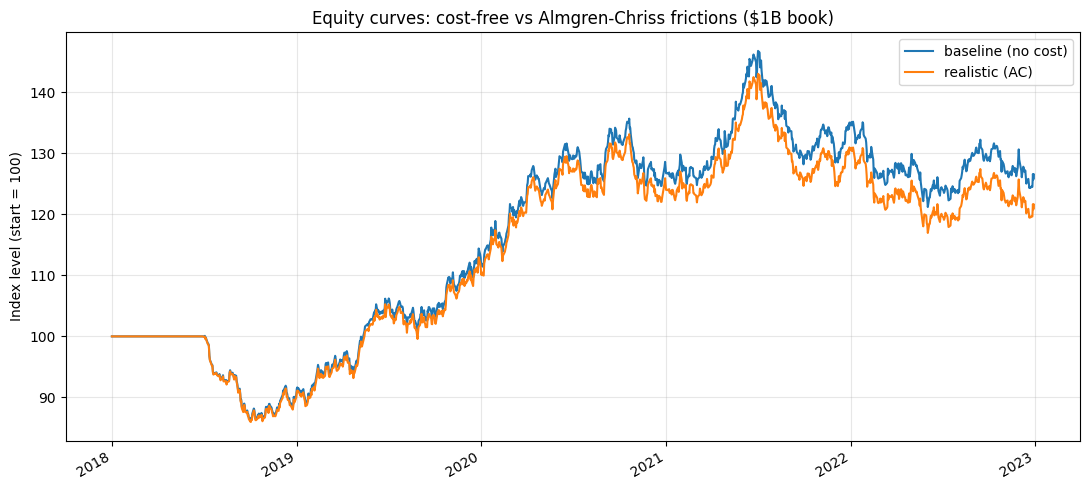

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
result.prices.plot(ax=ax, lw=1.5)
ax.set_title('Equity curves: cost-free vs Almgren-Chriss frictions ($1B book)')
ax.set_ylabel('Index level (start = 100)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cost attribution

Inspecting fees paid and traded notional side by side. With Almgren-Chriss, the
permanent + depth components scale with `|q|/V` — i.e. *participation rate* —
so a billion-dollar rebalance pays cost on top of the spread.

In [6]:
def summarise(bkt, label):
    fees_total = float(bkt.strategy.fees.sum())
    final_value = float(bkt.strategy.values.iloc[-1])
    # gross traded notional, summed over all child securities
    traded_notional = sum(abs(sec.outlays).sum() for sec in bkt.strategy.securities)
    return {
        'strategy'             : label,
        'final equity ($M)'    : final_value / 1e6,
        'total return (%)'     : 100 * (final_value / INITIAL_CAPITAL - 1),
        'gross traded ($B)'    : traded_notional / 1e9,
        'total fees ($M)'      : fees_total / 1e6,
        'fees / traded (bps)'  : 1e4 * fees_total / max(traded_notional, 1.0),
    }

pd.DataFrame([summarise(baseline, 'baseline'), summarise(realistic, 'realistic')]).set_index('strategy')

,final equity ($M),total return (%),gross traded ($B),total fees ($M),fees / traded (bps)
strategy,,,,,
baseline,1265.262743,26.526274,35.432102,0.000000,0.000000
realistic,1215.902289,21.590229,34.717752,46.394005,13.363194


## How sensitive is the result to participation rate?

The Almgren-Chriss permanent and depth terms scale linearly in `|q|/V`. We
can see this directly by sweeping the available volume — a market where you
take a larger share of daily turnover charges you more, holding the same
trades constant.

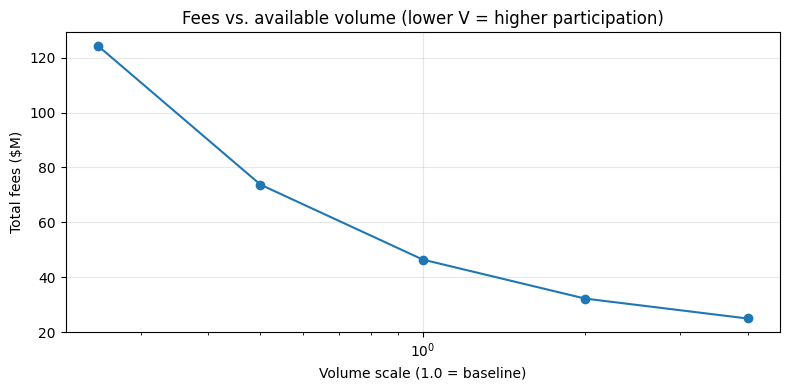

In [7]:
def run_with_volume_scale(scale):
    bkt = bt.Backtest(
        momentum_strategy(f'V x {scale}'),
        prices,
        commissions=AlmgrenChrissCostModel(alpha=1.0, beta=1.0, epsilon=0.0005),
        volume=volume * scale,
        volatility=volatility,
        initial_capital=INITIAL_CAPITAL,
        integer_positions=False,
        progress_bar=False,
    )
    bt.run(bkt)
    return float(bkt.strategy.fees.sum())

scales = [0.25, 0.5, 1.0, 2.0, 4.0]
fees = [run_with_volume_scale(s) for s in scales]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scales, np.array(fees) / 1e6, marker='o')
ax.set_xscale('log')
ax.set_xlabel('Volume scale (1.0 = baseline)')
ax.set_ylabel('Total fees ($M)')
ax.set_title('Fees vs. available volume (lower V = higher participation)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaway

Picking the cost model is a modeling choice with first-order consequences for
strategy evaluation. A flat-bps commission will flatter any strategy that
trades large notional relative to available liquidity. Passing a `CostModel`
to `bt.Backtest` makes that bias visible by routing trade quantities through
a model that scales with order size, market depth, and instrument
volatility — while leaving the existing callable-based usage of the
`commissions` argument unchanged.

## References

- Abbade, L. R., & Costa, A. H. R. (2026). *Realistic Market Impact Modeling
  for Reinforcement Learning Trading Environments.*
  [arXiv:2603.29086](https://arxiv.org/abs/2603.29086).
- Almgren, R., & Chriss, N. (2001). Optimal execution of portfolio
  transactions. *Journal of Risk* 3(2), 5-39.
- Tóth, B., et al. (2011). Anomalous Price Impact and the Critical Nature of
  Liquidity in Financial Markets. *Physical Review X* 1(2), 021006.
- Gatheral, J. (2010). No-Dynamic-Arbitrage and Market Impact. *Quantitative
  Finance* 10(7), 749-759.